# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan pada eksperimen ini adalah **Telco Customer Churn** (IBM sample dataset), diperoleh dari public repository (Kaggle).

**Ringkasan dataset:**
- Jumlah baris: 7.043 pelanggan
- Jumlah kolom: 21 (20 fitur + 1 target)
- Target: `Churn` (Yes/No) - apakah pelanggan berhenti berlangganan (churn) atau tidak
- Tipe masalah: **klasifikasi biner**

**Kelompok fitur:**
1. Demografi pelanggan: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
2. Informasi akun: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
3. Layanan yang digunakan: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

File raw disimpan di `../namadataset_raw/Telco-Customer-Churn.csv`.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [17]:
#Type your code here
#Import libraries for data processing & transformation
import pandas as pd
import numpy as np

#Import libraries for data visualization process
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [18]:
#Type your code here
#Load the Telco Customer Churn dataset
df = pd.read_csv('../namadataset_raw/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
#Checking the dataset shape and data types
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 4.1 Distribusi Target (Churn)


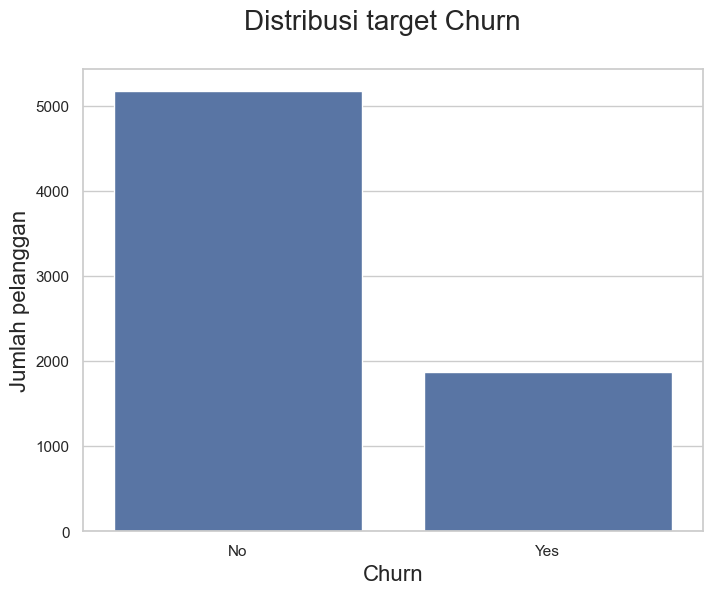

In [20]:
#Type your code here
#Checking target class distribution (churn vs not churn)
fig = plt.figure(figsize=(8,6))
ax = plt.axes()
sns.countplot(x='Churn', data=df, ax=ax)
sns.set(font_scale=1.5)

ax.set_xlabel('Churn', fontsize=16)
ax.set_ylabel('Jumlah pelanggan', fontsize=16)
fig.suptitle('Distribusi target Churn', fontsize=20)

plt.show()

**Insight:** Data imbalanced — 5.174 pelanggan (73,5%) tidak churn, 1.869 pelanggan (26,5%) churn. Perlu diperhatikan saat modelling (metrik akurasi saja tidak cukup, precision/recall/F1 lebih relevan).


## 4.2 Distribusi Fitur Numerik (tenure & MonthlyCharges)


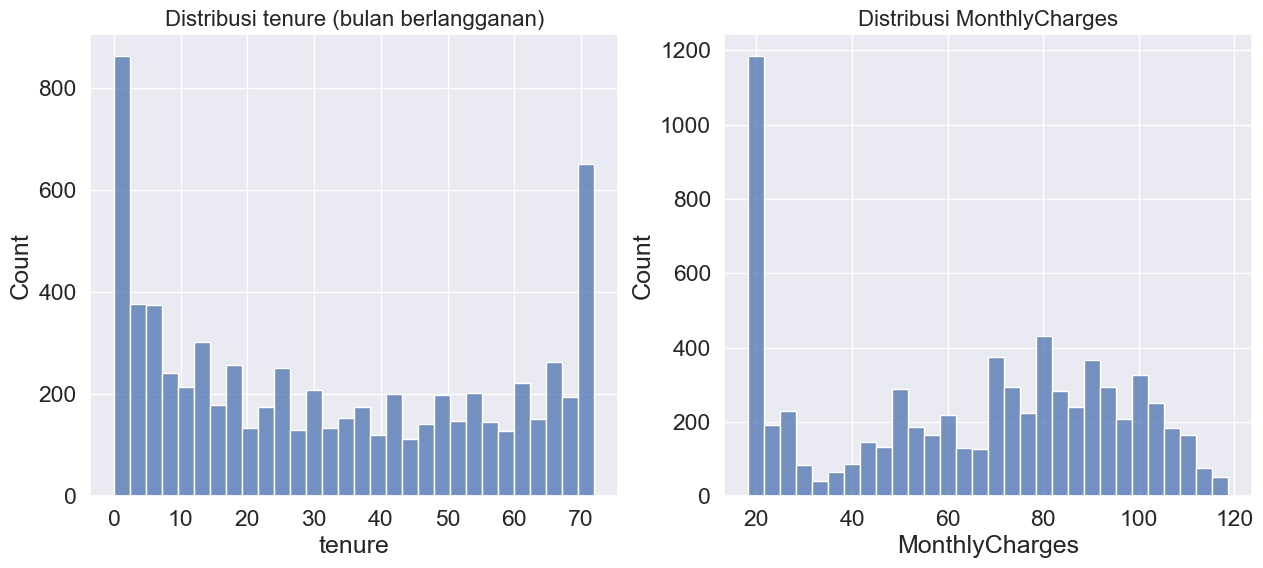

In [21]:
#Checking numerical feature distribution (tenure, MonthlyCharges)
fig, axes = plt.subplots(1, 2, figsize=(15,6))
sns.set(font_scale=1.2)

sns.histplot(df['tenure'], bins=30, ax=axes[0])
axes[0].set_title('Distribusi tenure (bulan berlangganan)', fontsize=16)

sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1])
axes[1].set_title('Distribusi MonthlyCharges', fontsize=16)

plt.show()

**Insight:** `tenure` menumpuk di pelanggan baru (<10 bulan) dan pelanggan lama (>60 bulan) — pola bimodal. `MonthlyCharges` tersebar cukup merata, dengan sebagian besar pelanggan di kisaran $20 (paket dasar) dan $70-100 (paket lengkap).


## 4.3 Churn Berdasarkan Tipe Kontrak


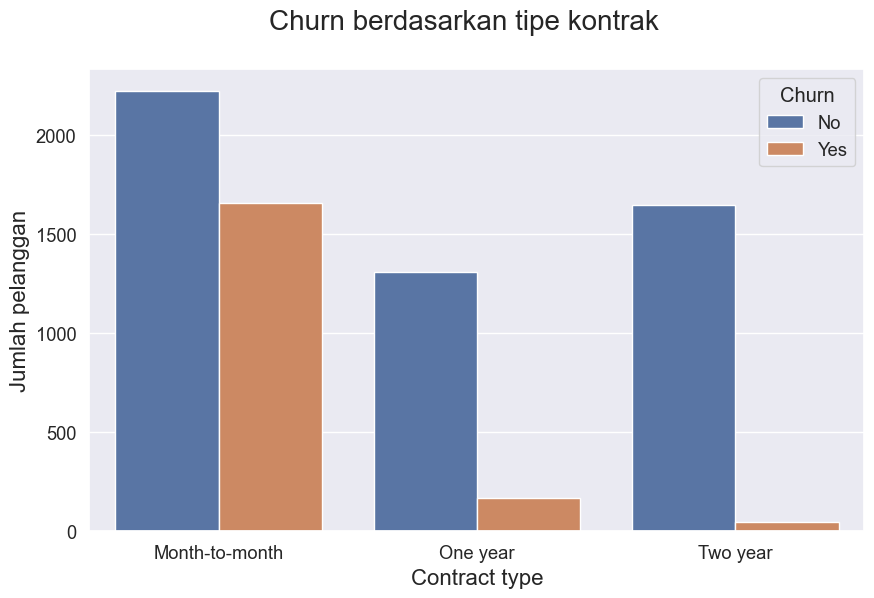

In [22]:
#Checking churn rate based on contract type
fig = plt.figure(figsize=(10,6))
ax = plt.axes()
sns.countplot(x='Contract', hue='Churn', data=df, ax=ax)
sns.set(font_scale=1.5)

ax.set_xlabel('Contract type', fontsize=16)
ax.set_ylabel('Jumlah pelanggan', fontsize=16)
fig.suptitle('Churn berdasarkan tipe kontrak', fontsize=20)

plt.show()


**Insight:** Churn paling tinggi pada kontrak `Month-to-month`, jauh lebih rendah pada `One year`/`Two year`. Wajar — pelanggan tanpa komitmen jangka panjang lebih mudah pindah.


## 4.4 Churn Berdasarkan Layanan Internet


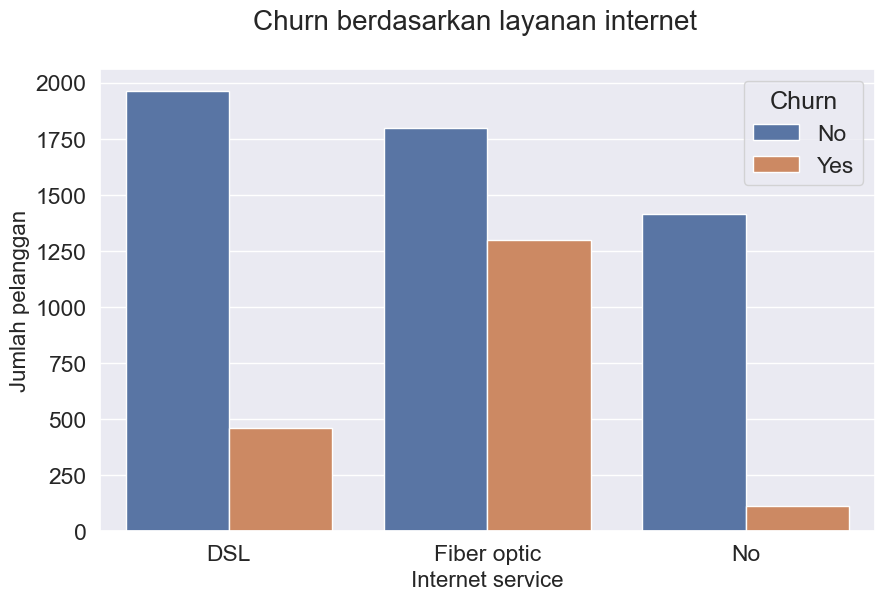

In [23]:
#Checking churn rate based on internet service type
fig = plt.figure(figsize=(10,6))
ax = plt.axes()
sns.countplot(x='InternetService', hue='Churn', data=df, ax=ax)
sns.set(font_scale=1.5)

ax.set_xlabel('Internet service', fontsize=16)
ax.set_ylabel('Jumlah pelanggan', fontsize=16)
fig.suptitle('Churn berdasarkan layanan internet', fontsize=20)

plt.show()

**Insight:** Pelanggan `Fiber optic` punya churn rate tertinggi, lebih tinggi dari `DSL` maupun tanpa internet (`No`). Kemungkinan terkait harga fiber yang lebih mahal atau isu kualitas layanan.


## 4.5 Korelasi Antar Fitur Numerik


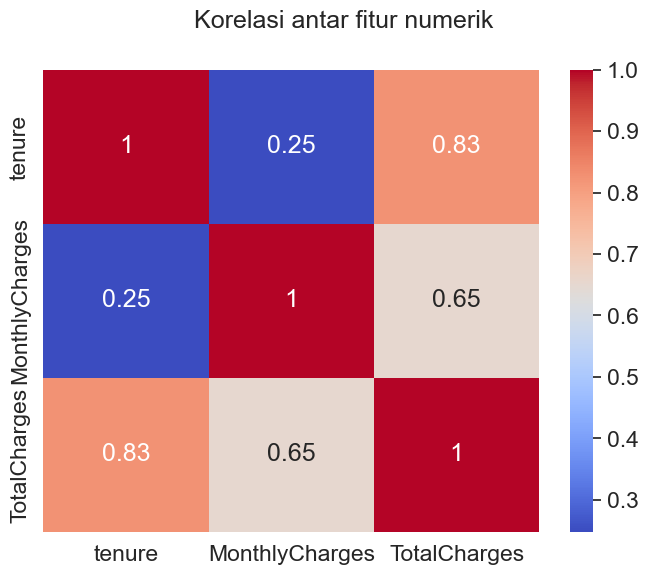

In [24]:
#Checking correlation between numerical features
#Note: TotalCharges masih bertipe object (akan diperbaiki di tahap preprocessing),
#      di sini kita convert sementara khusus untuk visualisasi korelasi.
numeric_preview = df[['tenure', 'MonthlyCharges']].copy()
numeric_preview['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(numeric_preview.corr(), annot=True, cmap='coolwarm', ax=ax)
fig.suptitle('Korelasi antar fitur numerik', fontsize=18)

plt.show()

**Insight:** `tenure` dan `TotalCharges` berkorelasi kuat positif (wajar — makin lama berlangganan, makin besar total tagihan). `MonthlyCharges` berkorelasi lemah dengan `tenure`, artinya besar tagihan bulanan tidak terlalu terkait lama berlangganan.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Tahapan preprocessing yang dilakukan:
1. Drop kolom identifier (`customerID`)
2. Perbaiki tipe data `TotalCharges` (object -> numeric) dan tangani hidden missing value
3. Cek data duplikat
4. Normalisasi nilai `"No internet service"` / `"No phone service"` menjadi `"No"` (secara semantik sama)
5. Encoding kolom kategorikal (binary encoding & one-hot encoding)
6. Simpan hasil preprocessing ke `namadataset_preprocessing/`


## 5.1 Drop Kolom Identifier

In [25]:
#Dropping identifier column (not a predictive feature)
df_clean = df.drop(columns=['customerID'])
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5.2 Perbaikan Tipe Data & Deteksi Missing Value

In [26]:
#Fixing TotalCharges data type (object -> numeric)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

#Detecting every NaN value on every columns
df_clean.isnull().sum()


gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## 5.3 Penanganan Missing Value dan cek data duplicate


In [27]:
#Removing data with NaN value (hidden missing value pada TotalCharges)
prev_size = df_clean.shape[0]
df_clean.dropna(how='any', inplace=True)
current_size = df_clean.shape[0]

print(df_clean.shape)
print('Dari data cleaning, kita membuang {}% data karena NaN value'.format(round(((prev_size - current_size)/prev_size)*100, 2)))


(7032, 20)
Dari data cleaning, kita membuang 0.16% data karena NaN value


In [28]:
#Checking duplicate rows
print('Jumlah baris duplikat:', df_clean.duplicated().sum())


Jumlah baris duplikat: 22


## 5.4 Normalisasi Kategori


In [29]:
#Normalizing "No internet service" / "No phone service" into "No" (semantically the same)
service_cols_with_no_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols_with_no_internet:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')

df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5.5 Encoding Fitur Kategorikal


In [30]:
#Label and one hot encoding process
#Handling column with 2 distinct value (binary Yes/No & gender)
binary_yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in binary_yes_no_cols:
    df_clean[col] = df_clean[col].map({'No': 0, 'Yes': 1}).astype(int)

df_clean['gender'] = df_clean['gender'].map({'Female': 0, 'Male': 1}).astype(int)

#Handling column with more than 2 distinct value (one hot encoding)
multi_category_cols = ['Contract', 'InternetService', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=multi_category_cols, drop_first=False)

df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,False,True,False,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,False,True,False,True,False,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False


In [31]:
#Result of data preprocessing
print(df_clean.shape)
df_clean.info()

(7032, 27)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int64  
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   MultipleLines                            7032 non-null   int64  
 7   OnlineSecurity                           7032 non-null   int64  
 8   OnlineBackup                             7032 non-null   int64  
 9   DeviceProtection                         7032 non-null   int64  
 10  TechSupport                              7

## 5.6 Simpan Dataset Hasil Preprocessing


In [32]:
#Saving the preprocessed dataset (ready to be trained on Kriteria 2)
import os

output_dir = 'namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'telco_churn_preprocessed.csv')
df_clean.to_csv(output_path, index=False)

print(f'Preprocessed dataset disimpan di: {output_path}')


Preprocessed dataset disimpan di: namadataset_preprocessing\telco_churn_preprocessed.csv
